# Step 1: Data Preparation

In [2]:
import os
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
current_working_directory = os.getcwd()
home_dir = os.path.abspath(os.path.join(current_working_directory, os.pardir))
data_path = os.path.join(home_dir, 'data/')

## 1. Categorical and Numeric features

In [4]:
cat_input = pd.read_excel(os.path.join(data_path, 'TRAIN/TRAIN_CATEGORICAL_METADATA.xlsx'))
quant_input = pd.read_excel(os.path.join(data_path, 'TRAIN/TRAIN_QUANTITATIVE_METADATA.xlsx'))
labels = pd.read_excel(os.path.join(data_path, 'TRAIN/TRAINING_SOLUTIONS.xlsx'))

In [14]:
input_merged_1 = pd.merge(quant_input, cat_input, on='participant_id', how='inner')

In [16]:
input_merged_1 = pd.merge(input_merged_1, labels, on='participant_id', how='inner')

In [17]:
input_merged_1

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,...,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ,ADHD_Outcome,Sex_F
0,UmrK0vMLopoR,40.00,13,3,10,47,13,11,28,0,...,1,0.0,0,1,21,45,21,45,1,1
1,CPaeQkhcjg7d,-94.47,14,3,13,34,18,23,30,0,...,3,1.0,2,3,15,15,0,0,1,0
2,Nb4EetVPm3gs,-46.67,14,4,10,35,16,10,29,1,...,1,1.0,8,1,18,40,0,0,1,0
3,p4vPhVu91o4b,-26.68,10,5,12,39,19,16,28,6,...,3,0.0,8,3,15,30,18,0,1,1
4,M09PXs7arQ5E,0.00,14,5,15,40,20,24,28,1,...,3,0.0,1,3,15,20,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,Atx7oub96GXS,87.80,14,5,14,39,20,15,21,1,...,1,0.0,0,2,21,40,21,40,0,0
1209,groSbUfkQngM,77.80,14,3,10,32,20,11,23,6,...,1,0.0,0,1,18,35,0,0,0,1
1210,zmxGvIrOD0bt,16.68,14,3,16,28,15,19,27,3,...,1,1.0,2,1,18,20,0,0,0,1
1211,rOmWFuJCud5G,53.40,14,3,14,34,18,23,23,4,...,3,0.0,8,3,21,40,18,45,0,0


In [18]:
input_merged_1.to_csv(os.path.join(data_path, 'intermediate/train_merged_small.csv'), index=False)

/Applications/anaconda3/envs/wids-env/lib/python3.10/site-packages/pandas/core/internals/blocks.py:2323: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)


## 2. High Dimensional Data Input

In [5]:
func_connectome_input = pd.read_csv(os.path.join(data_path, 'TRAIN/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.csv'))


In [4]:
func_connectome_input.shape

(1213, 19901)

In [ ]:
columns_1stcol = ['participant_id']+[c for c in func_connectome_input.columns if c.endswith('_4thcolumn')]
dat_1stcol = func_connectome_input[columns_1stcol]
dat_1stcol

In [6]:
columns_0throw = ['participant_id'] + [c for c in func_connectome_input.columns if c.startswith('0throw')]
dat_0throw = func_connectome_input[columns_0throw]

In [5]:
# Compute the correlation matrix
corr_matrix = func_connectome_input.corr(method='spearman')
# corr_matrix

/var/folders/9r/8c_k_4cj5571k3ct1nx0vtth0000gn/T/ipykernel_32158/3649167769.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = func_connectome_input.corr(method='spearman')


In [7]:
corr_matrix = dat_0throw.corr(method='spearman')

/var/folders/9r/8c_k_4cj5571k3ct1nx0vtth0000gn/T/ipykernel_34141/940924531.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = dat_0throw.corr(method='spearman')


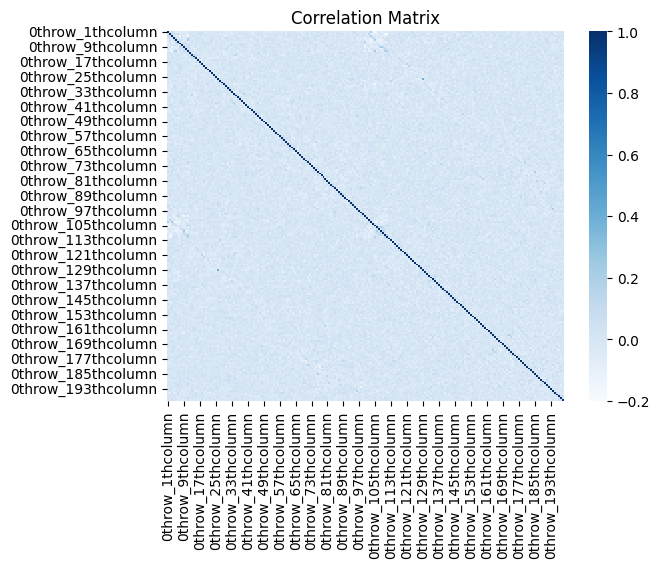

In [8]:
sns.heatmap(corr_matrix, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

/var/folders/9r/8c_k_4cj5571k3ct1nx0vtth0000gn/T/ipykernel_34141/94444356.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = dat_1throw.corr(method='spearman')


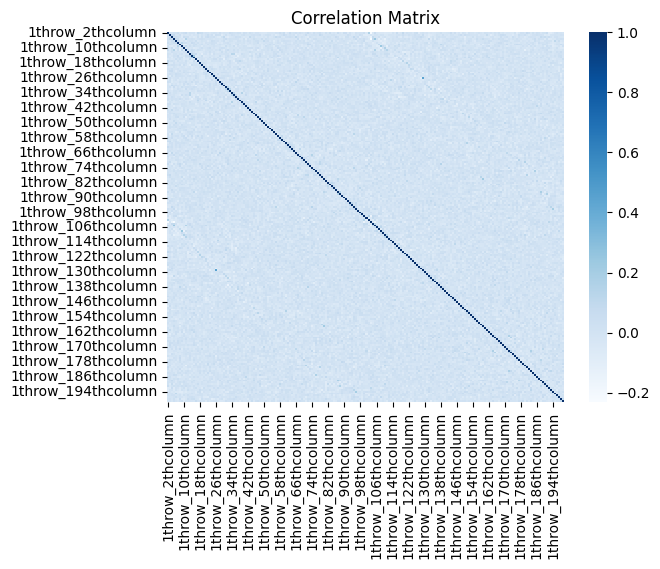

In [9]:
columns_1throw = ['participant_id'] + [c for c in func_connectome_input.columns if c.startswith('1throw')]
dat_1throw = func_connectome_input[columns_1throw]

corr_matrix = dat_1throw.corr(method='spearman')

sns.heatmap(corr_matrix, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

In [10]:
# Calculate mean and standard deviation
mean_values = dat_0throw.mean()
std_values = dat_0throw.std()

/var/folders/9r/8c_k_4cj5571k3ct1nx0vtth0000gn/T/ipykernel_34141/996408965.py:2: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  mean_values = dat_0throw.mean()
/var/folders/9r/8c_k_4cj5571k3ct1nx0vtth0000gn/T/ipykernel_34141/996408965.py:3: FutureWarning: The default value of numeric_only in DataFrame.std is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  std_values = dat_0throw.std()


/var/folders/9r/8c_k_4cj5571k3ct1nx0vtth0000gn/T/ipykernel_34141/2275319073.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
/var/folders/9r/8c_k_4cj5571k3ct1nx0vtth0000gn/T/ipykernel_34141/2275319073.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)


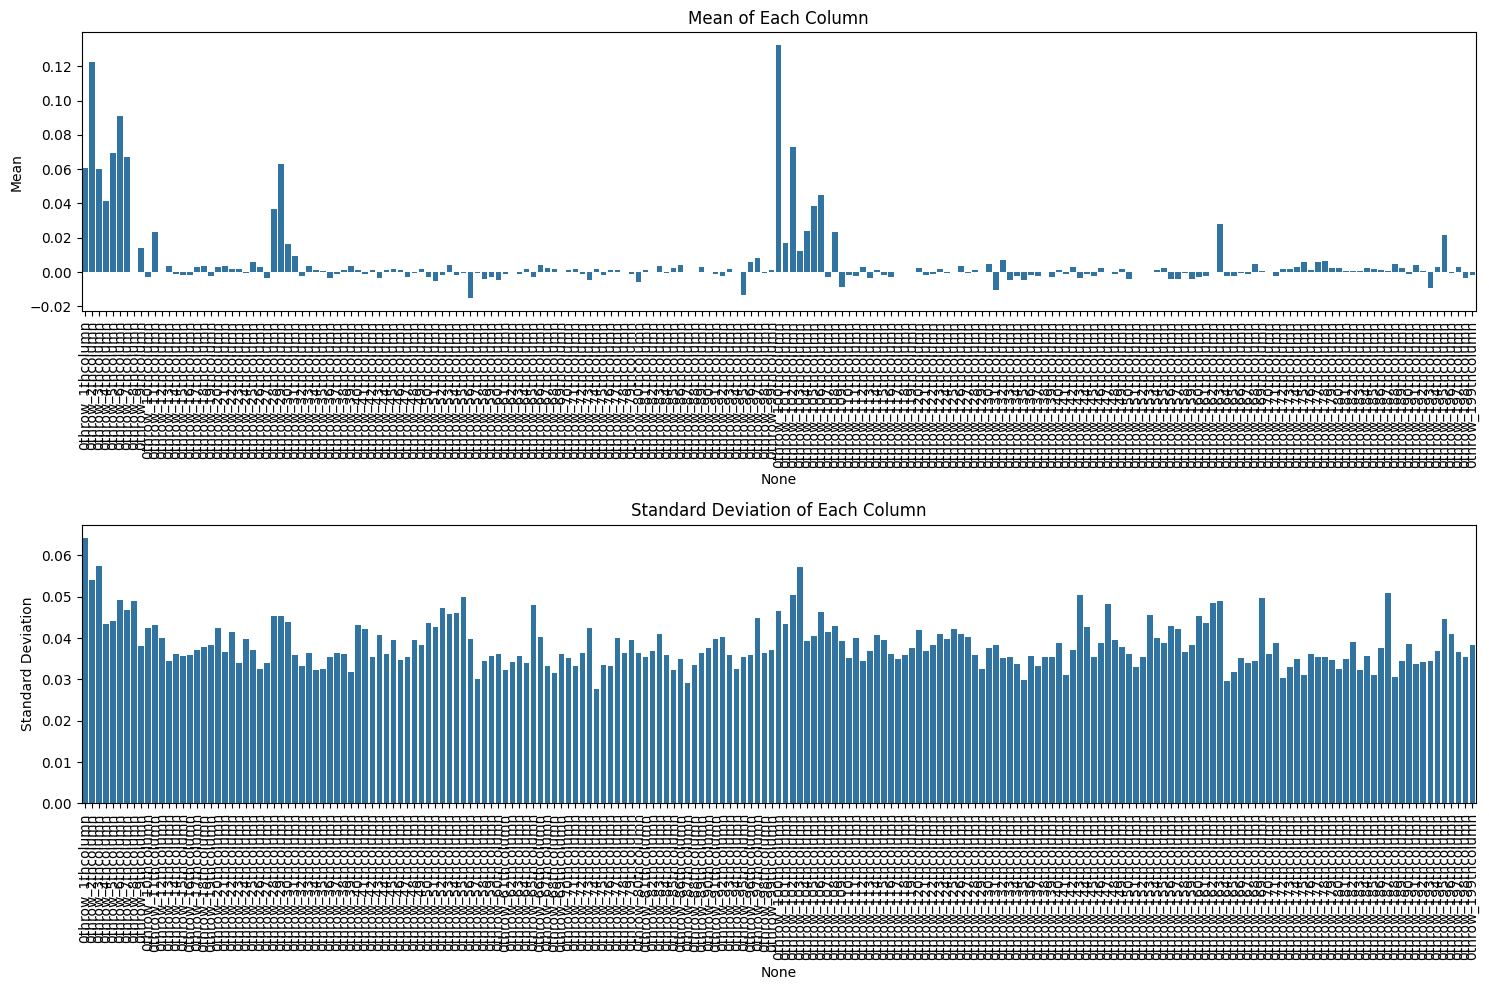

In [11]:
# Create a new dataframe to hold the mean and standard deviation
stats_df = pd.DataFrame({'Mean': mean_values, 'Standard Deviation': std_values})

# Plot the mean and standard deviation
fig, ax = plt.subplots(2, 1, figsize=(15, 10))

# Plot mean values
sns.barplot(x=stats_df.index, y=stats_df['Mean'], ax=ax[0])
ax[0].set_title('Mean of Each Column')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)

# Plot standard deviation values
sns.barplot(x=stats_df.index, y=stats_df['Standard Deviation'], ax=ax[1])
ax[1].set_title('Standard Deviation of Each Column')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

### PCA 

In [12]:
input_merged_hd = pd.merge(func_connectome_input, labels, on='participant_id', how='inner')

In [13]:
input_merged_hd.shape

(1213, 19903)

In [18]:
pca_input = func_connectome_input.drop('participant_id', axis=1, inplace=True)

In [19]:
from sklearn.decomposition import PCA

pca_hd = PCA(n_components=10)
principalComponents_HD = pca_hd.fit_transform(pca_input)

ValueError: Expected 2D array, got scalar array instead:
array=nan.
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.